In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import squidpy as sq
import decoupler as dc
import enrichmap as em
import matplotlib.pyplot as plt
import numpy as np

from score_signatures import score_signatures

In [4]:
sc.set_figure_params(frameon=False)
sc.settings._vector_friendly = False

In [5]:
# set working directory
# repository root (the folder containing `notebooks/`); safe to re-run this cell
project_dir = os.getcwd()
if os.path.basename(project_dir) == "notebooks":
    project_dir = os.path.dirname(project_dir)
project_dir += "/"
working_dir = project_dir + ""
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"
os.makedirs(figure_dir, exist_ok=True)

# processed data directory
processed_data = working_dir + "processed_data/"
os.makedirs(processed_data, exist_ok=True)


In [6]:
adata = sq.datasets.visium_hne_adata()

In [7]:
adata.layers["counts"] = adata.raw.X.copy()

In [8]:
adata.X = adata.layers["counts"].copy()

In [9]:
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["log1p_norm"] = adata.X.copy()

#### Scoring for irrelevant signatures

In [10]:
markers = dc.op.resource("PanglaoDB", organism="mouse")
# Filter by canonical_marker and mouse
markers = markers[
    markers["mouse"].astype(bool)
    & markers["canonical_marker"].astype(bool)
    & (markers["mouse_sensitivity"].astype(float) > 0.5)
]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]

In [11]:
unit_test_markers = markers[markers["source"].isin(["Embryonic stem cells", "Hepatocytes", "Neurons", "Cardiomyocytes"])]
unit_test_markers_dict = unit_test_markers.groupby("source")["target"].apply(list).to_dict()
# 10 markers per cell type
signature_dict = {k: v[:10] for k, v in unit_test_markers_dict.items()}

In [12]:
adata = score_signatures(adata, signature_dict)

Scoring signatures: 100%|██████████| 1/1 [00:01<00:00,  1.79s/it]


In [13]:
enrichmap_scores = [
    "Cardiomyocytes_enrichmap",
    "Embryonic stem cells_enrichmap",
    "Hepatocytes_enrichmap",
    "Neurons_enrichmap",
]

aucell_scores = [
    "Cardiomyocytes_aucell",
    "Embryonic stem cells_aucell",
    "Hepatocytes_aucell",
    "Neurons_aucell",
]
scanpy_scores = [
    "Cardiomyocytes_scanpy",
    "Embryonic stem cells_scanpy",
    "Hepatocytes_scanpy",
    "Neurons_scanpy",
]
ssgsea_scores = [
    "Cardiomyocytes_ssgsea",
    "Embryonic stem cells_ssgsea",
    "Hepatocytes_ssgsea",
    "Neurons_ssgsea",
]
gsva_scores = [
    "Cardiomyocytes_gsva",
    "Embryonic stem cells_gsva",
    "Hepatocytes_gsva",
    "Neurons_gsva",
]
zscore_scores = [
    "Cardiomyocytes_zscore",
    "Embryonic stem cells_zscore",
    "Hepatocytes_zscore",
    "Neurons_zscore",
]

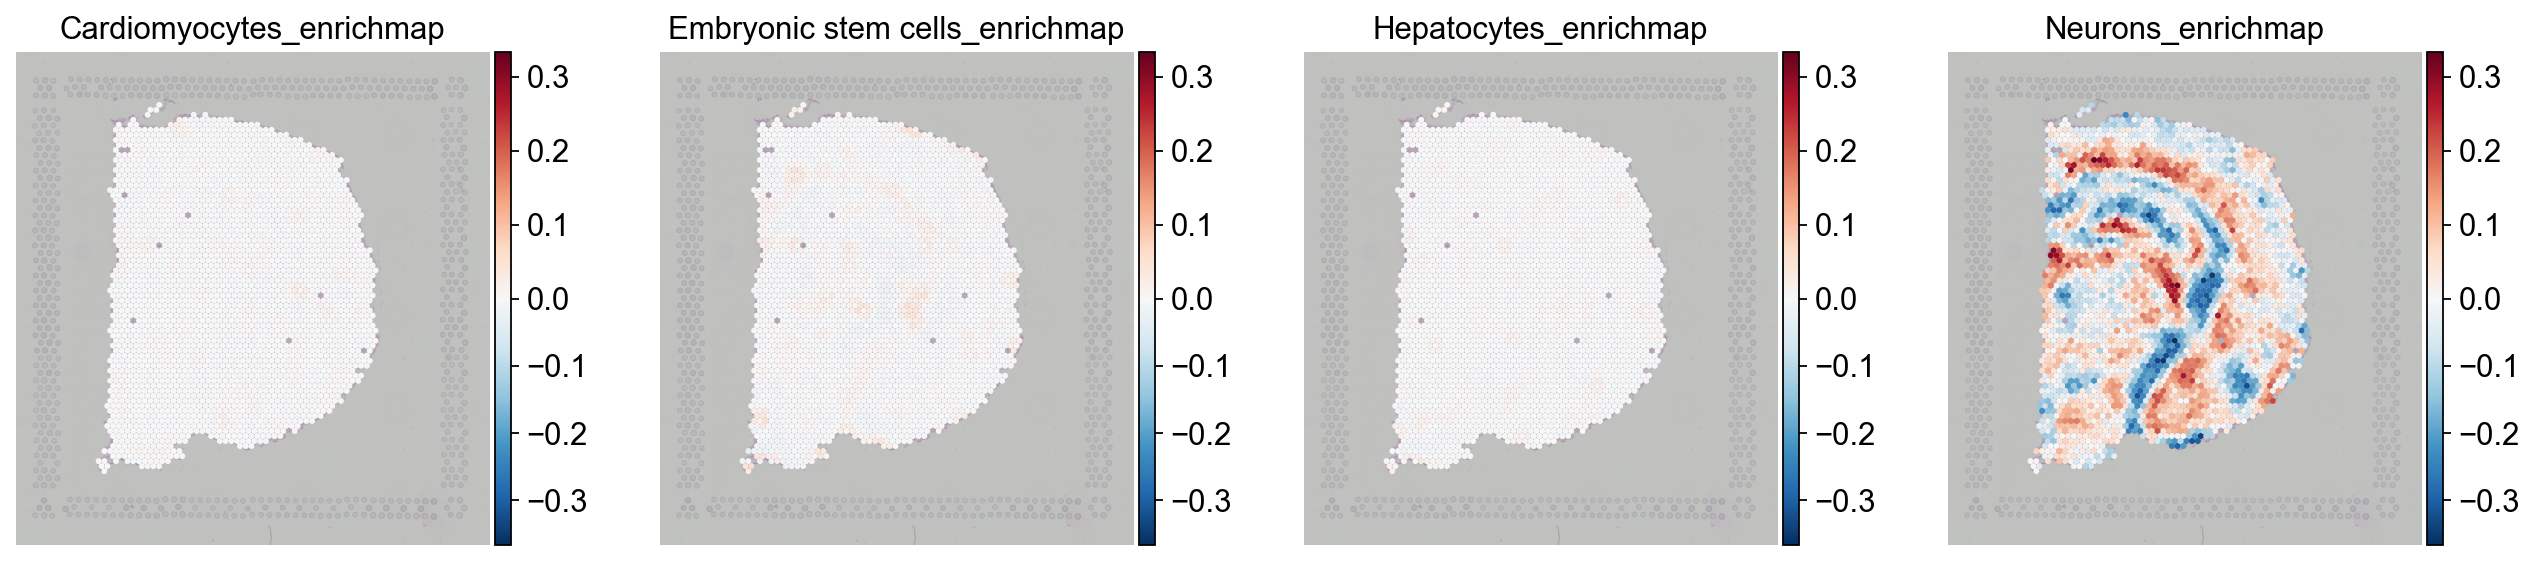

In [14]:
em.pl.spatial_enrichmap(
    adata,
    score_key=enrichmap_scores,
    cmap="RdBu_r",
    size=1.6,
    img_alpha=0.5,
    ncols=4,
    vmax=adata.obs["Neurons_enrichmap"].max(),
    vmin=adata.obs["Neurons_enrichmap"].min(),
    save="brain_enrichmap_score_unit_test.pdf",
)

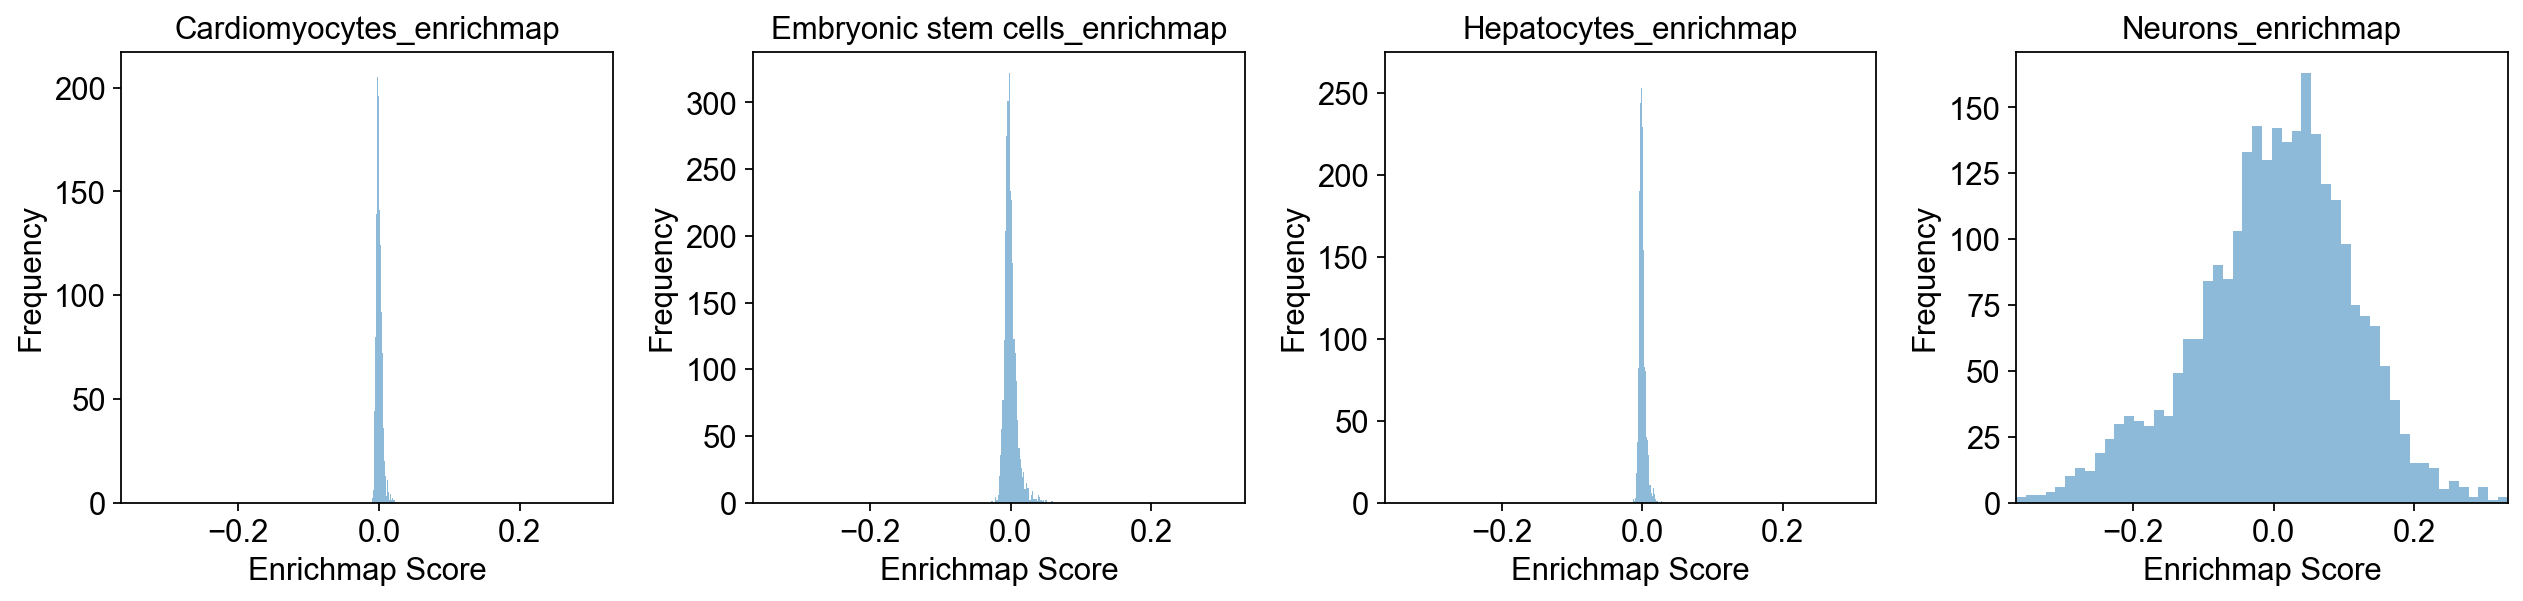

In [15]:
xmin = adata.obs["Neurons_enrichmap"].min()
xmax = adata.obs["Neurons_enrichmap"].max()

ncols = 4
nrows = int(np.ceil(len(enrichmap_scores) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for idx, score_col in enumerate(enrichmap_scores):
    ax = axes[idx // ncols, idx % ncols]
    ax.hist(adata.obs[score_col], bins=50, alpha=0.5)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Enrichmap Score")
    ax.set_ylabel("Frequency")
    ax.set_title(score_col)
    ax.grid(False)

for idx in range(len(enrichmap_scores), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

plt.tight_layout()
plt.savefig(figure_dir + "brain_enrichmap_score_unit_test_histogram.pdf")
plt.show()

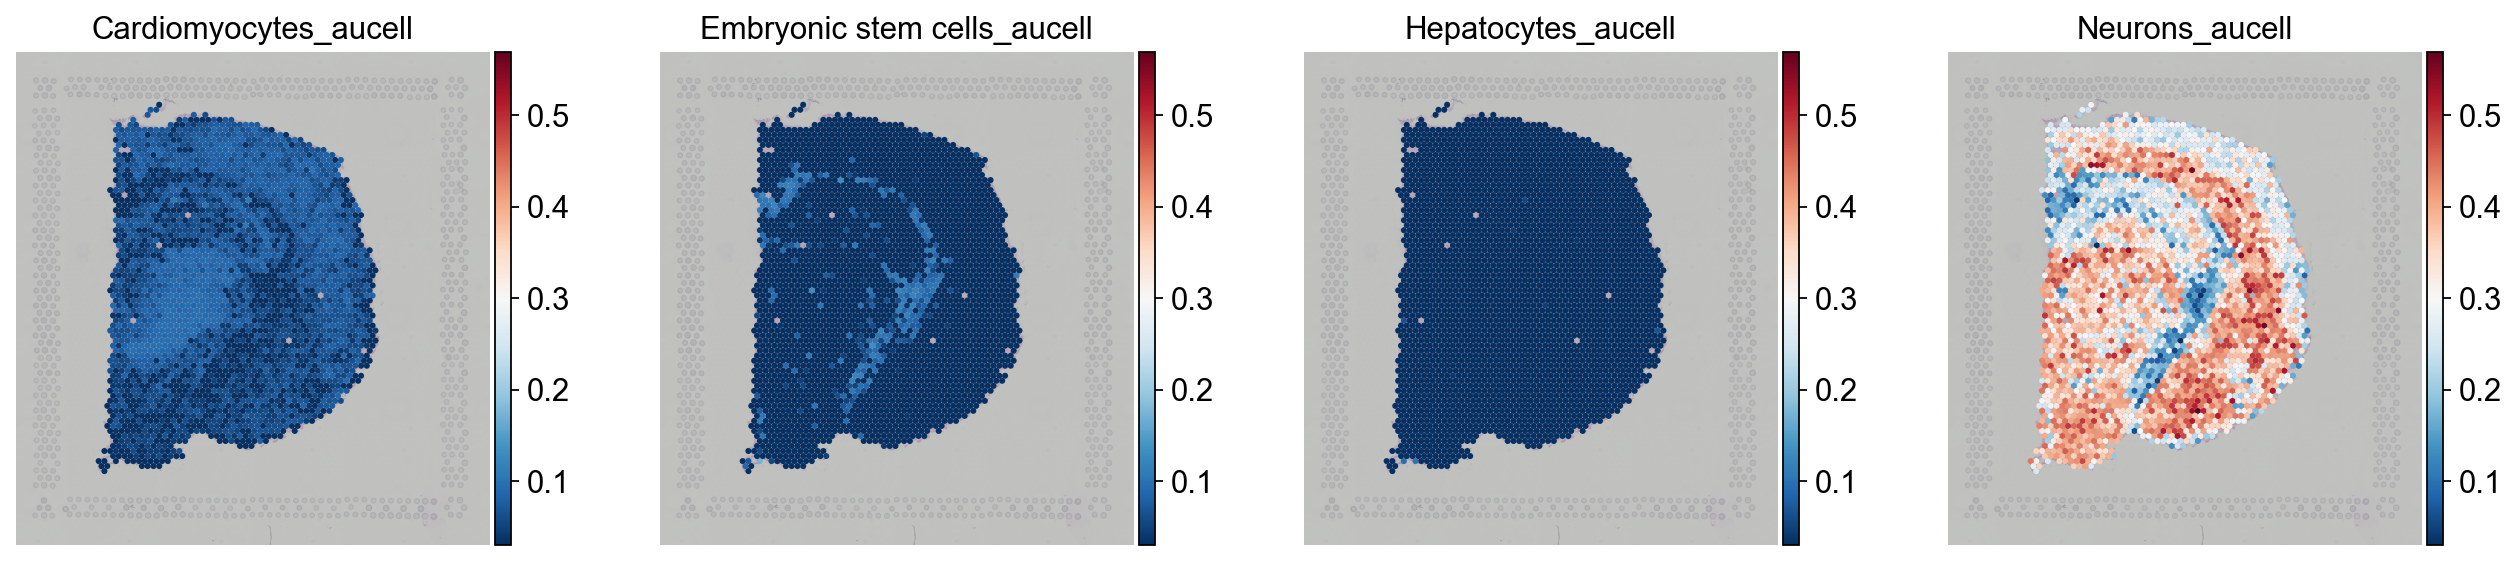

In [16]:
sq.pl.spatial_scatter(
    adata,
    color=aucell_scores,
    cmap="RdBu_r",
    size=1.6,
    img_alpha=0.5,
    ncols=4,
    vmax=adata.obs["Neurons_aucell"].max(),
    vmin=adata.obs["Neurons_aucell"].min(),
    save="brain_aucell_score_unit_test.pdf",
)

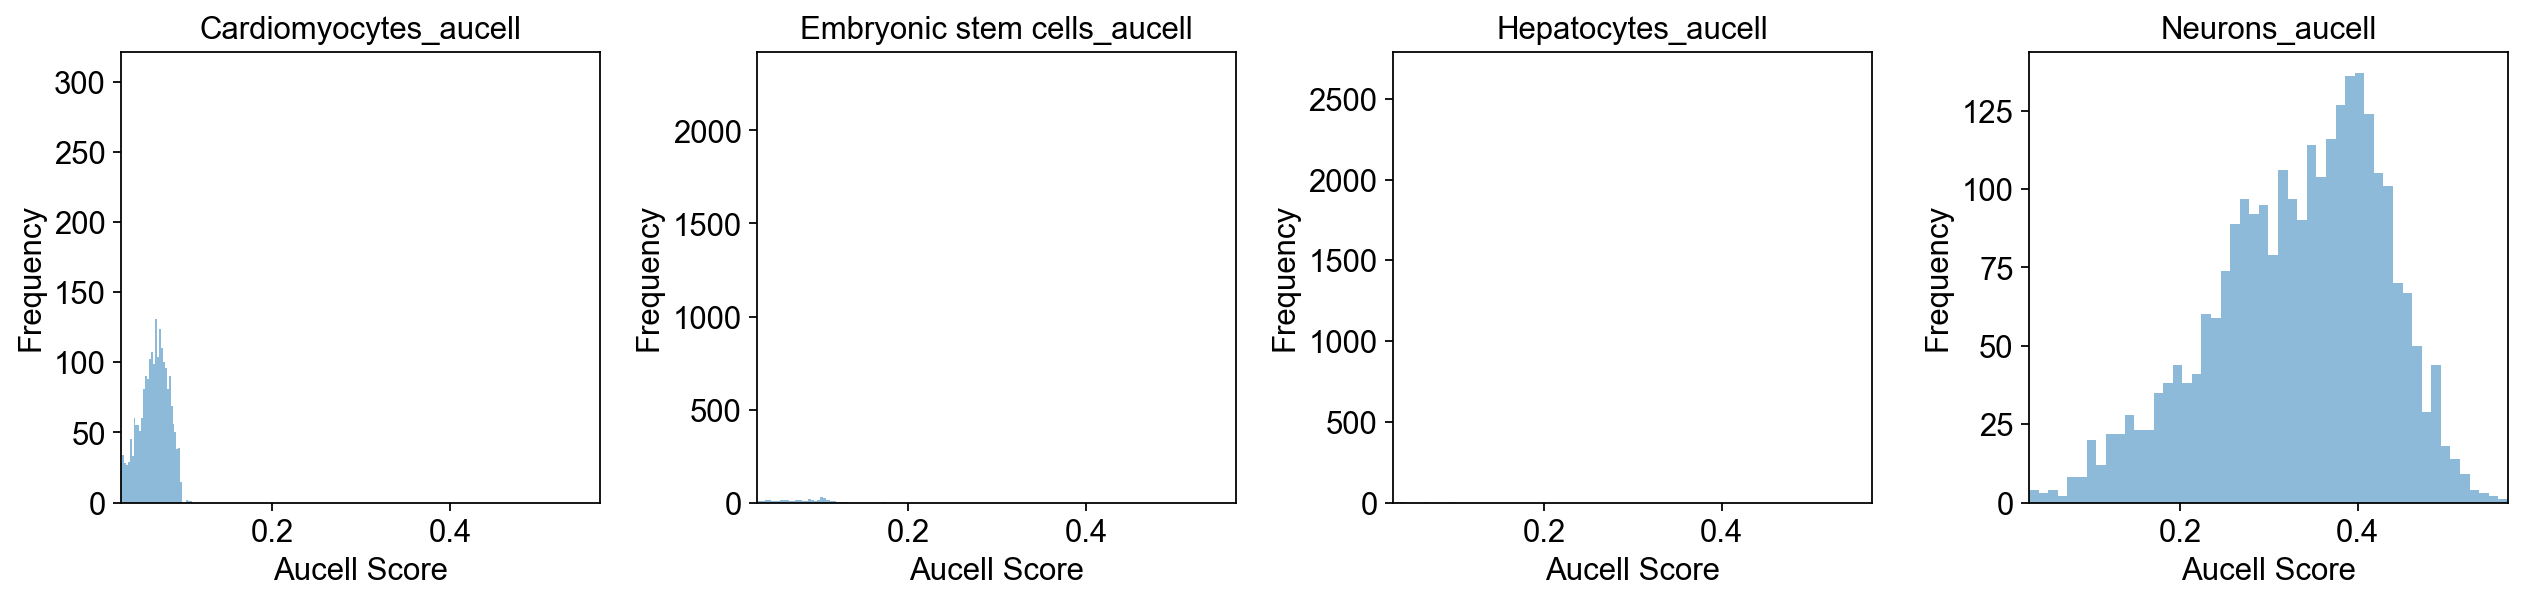

In [17]:
xmin = adata.obs["Neurons_aucell"].min()
xmax = adata.obs["Neurons_aucell"].max()

ncols = 4
nrows = int(np.ceil(len(aucell_scores) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for idx, score_col in enumerate(aucell_scores):
    ax = axes[idx // ncols, idx % ncols]
    ax.hist(adata.obs[score_col], bins=50, alpha=0.5)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Aucell Score")
    ax.set_ylabel("Frequency")
    ax.set_title(score_col)
    ax.grid(False)

for idx in range(len(aucell_scores), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

plt.tight_layout()
plt.savefig(figure_dir + "brain_aucell_score_unit_test_histogram.pdf")
plt.show()

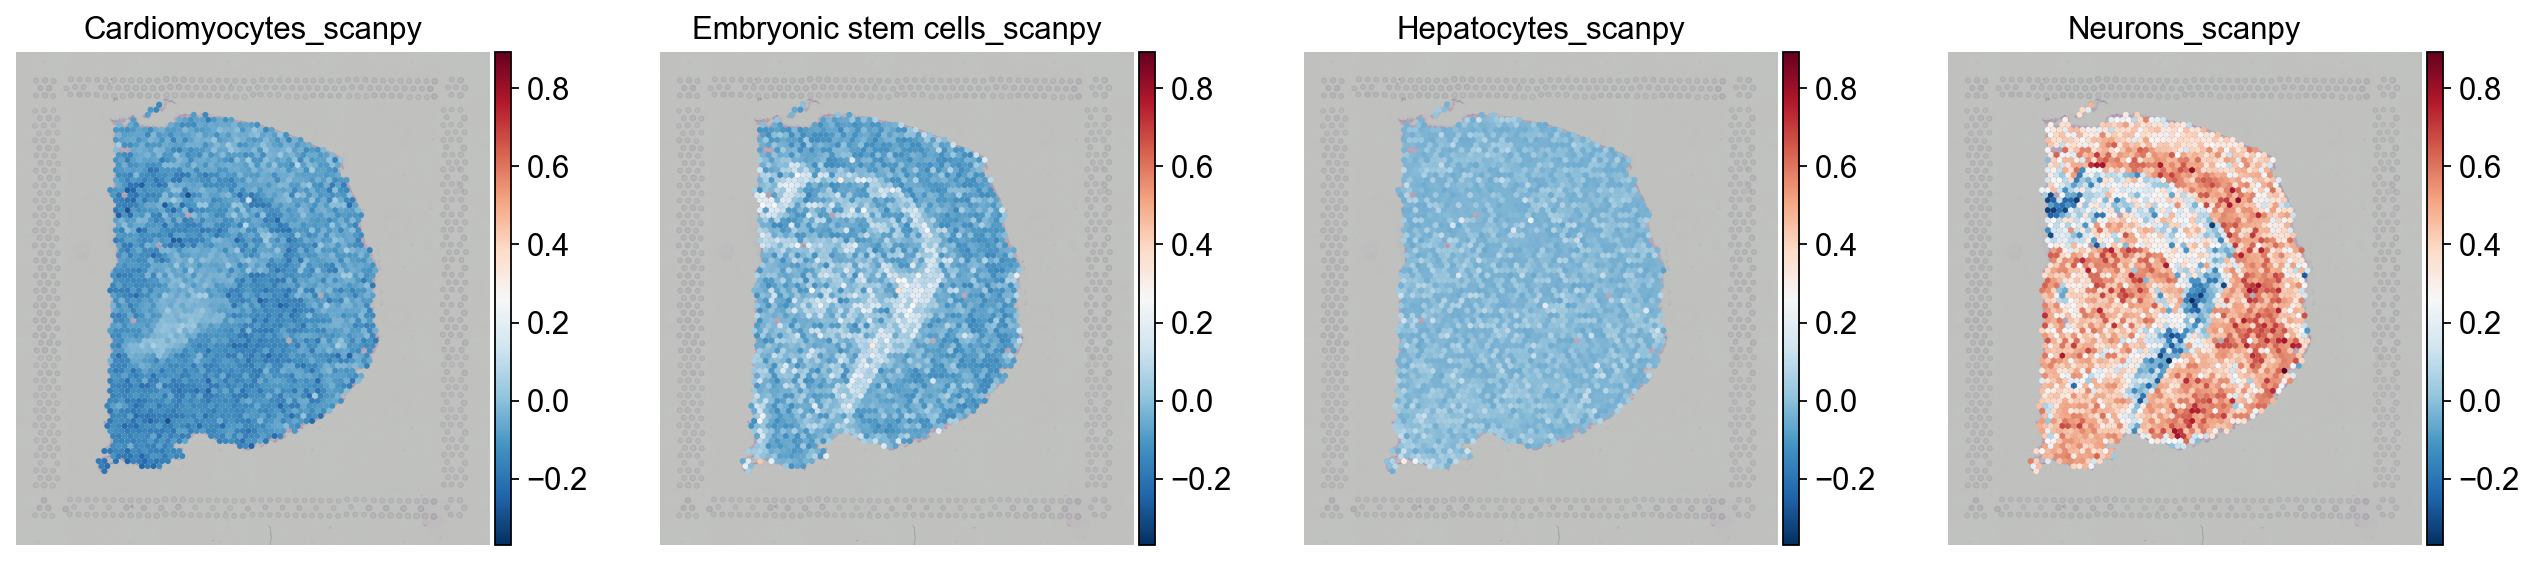

In [18]:
sq.pl.spatial_scatter(
    adata,
    color=scanpy_scores,
    cmap="RdBu_r",
    size=1.6,
    img_alpha=0.5,
    ncols=4,
    vmax=adata.obs["Neurons_scanpy"].max(),
    vmin=adata.obs["Neurons_scanpy"].min(),
    save="brain_scanpy_score_unit_test.pdf",
)

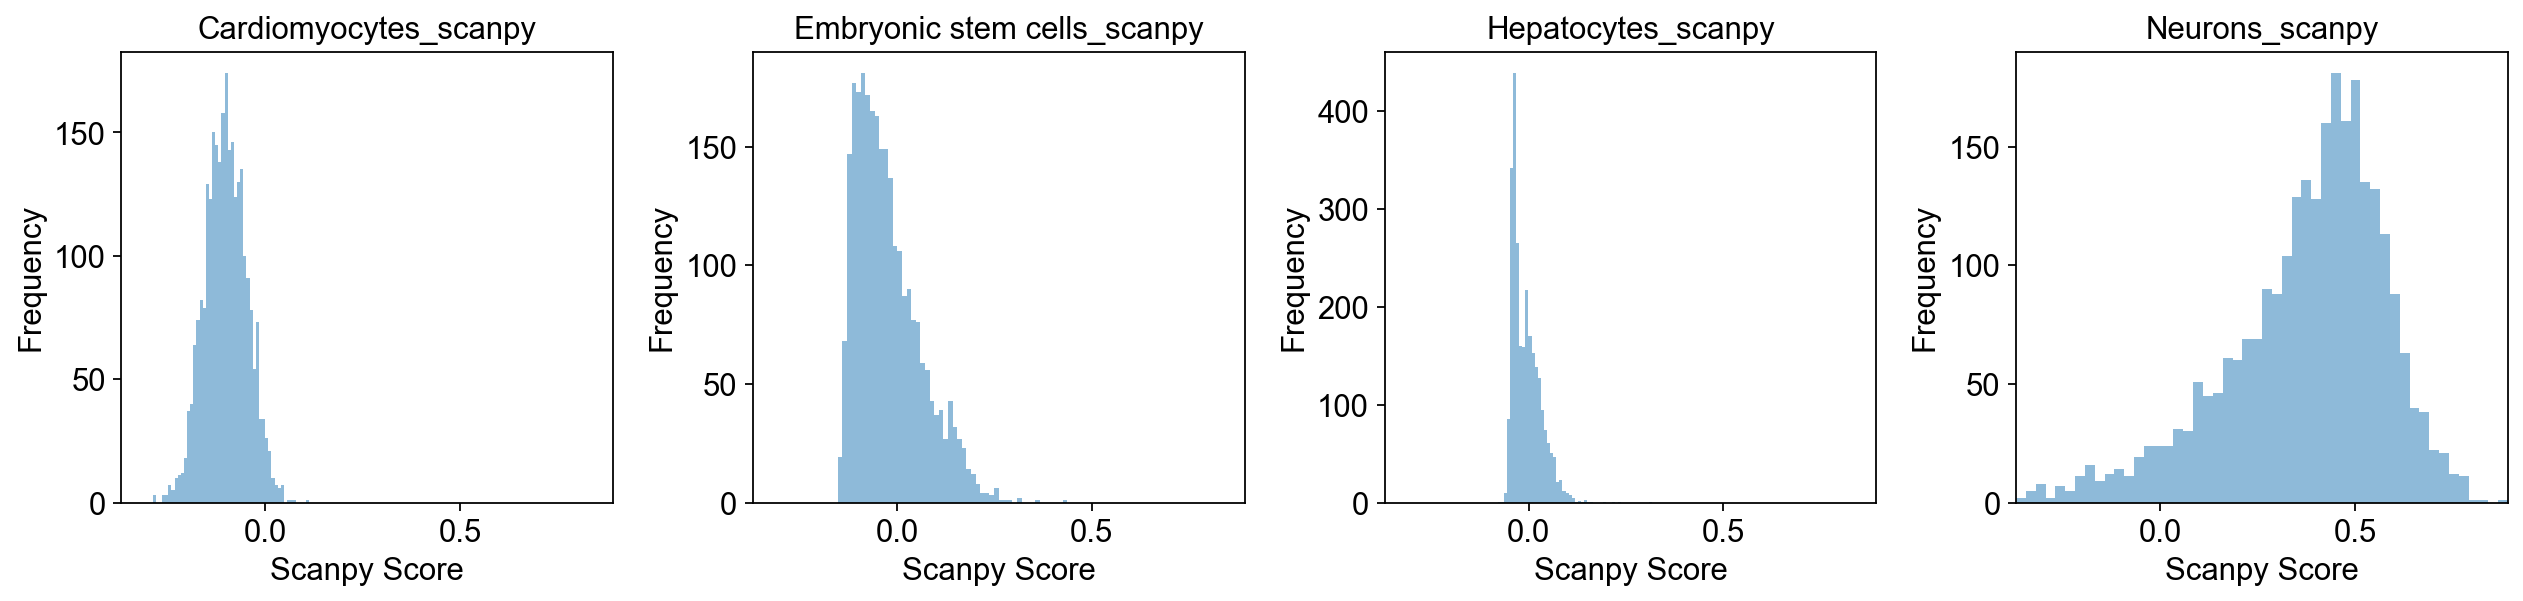

In [19]:
xmin = adata.obs["Neurons_scanpy"].min()
xmax = adata.obs["Neurons_scanpy"].max()

ncols = 4
nrows = int(np.ceil(len(scanpy_scores) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for idx, score_col in enumerate(scanpy_scores):
    ax = axes[idx // ncols, idx % ncols]
    ax.hist(adata.obs[score_col], bins=50, alpha=0.5)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Scanpy Score")
    ax.set_ylabel("Frequency")
    ax.set_title(score_col)
    ax.grid(False)

for idx in range(len(scanpy_scores), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

plt.tight_layout()
plt.savefig(figure_dir + "brain_scanpy_score_unit_test_histogram.pdf")
plt.show()

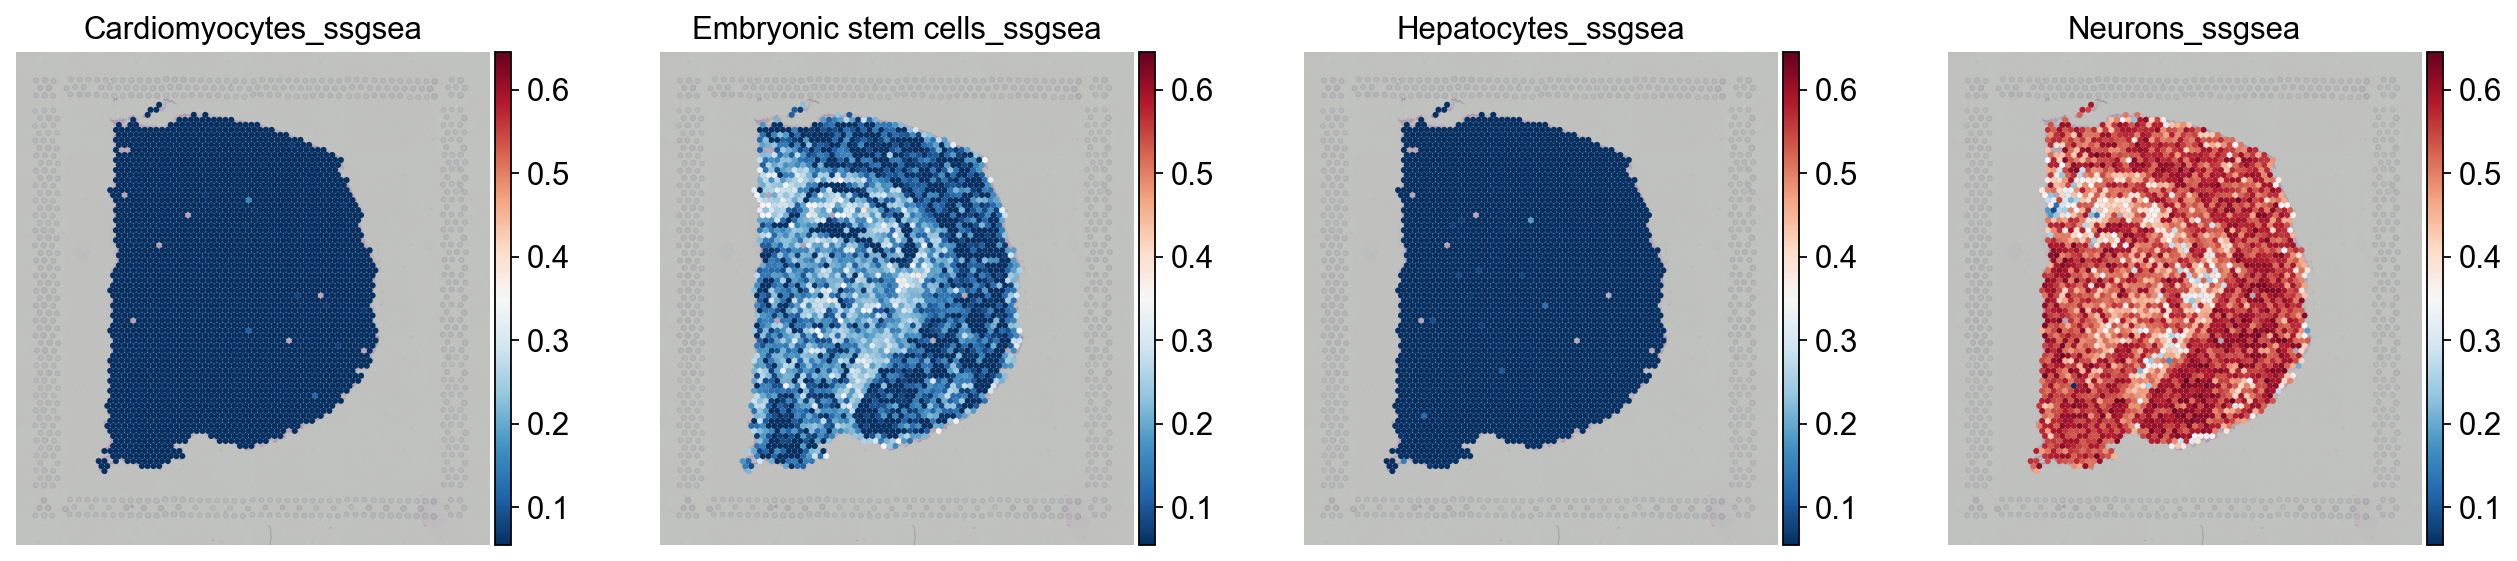

In [20]:
sq.pl.spatial_scatter(
    adata,
    color=ssgsea_scores,
    cmap="RdBu_r",
    size=1.6,
    img_alpha=0.5,
    ncols=4,
    vmax=adata.obs["Neurons_ssgsea"].max(),
    vmin=adata.obs["Neurons_ssgsea"].min(),
    save="brain_ssgsea_score_unit_test.pdf",
)

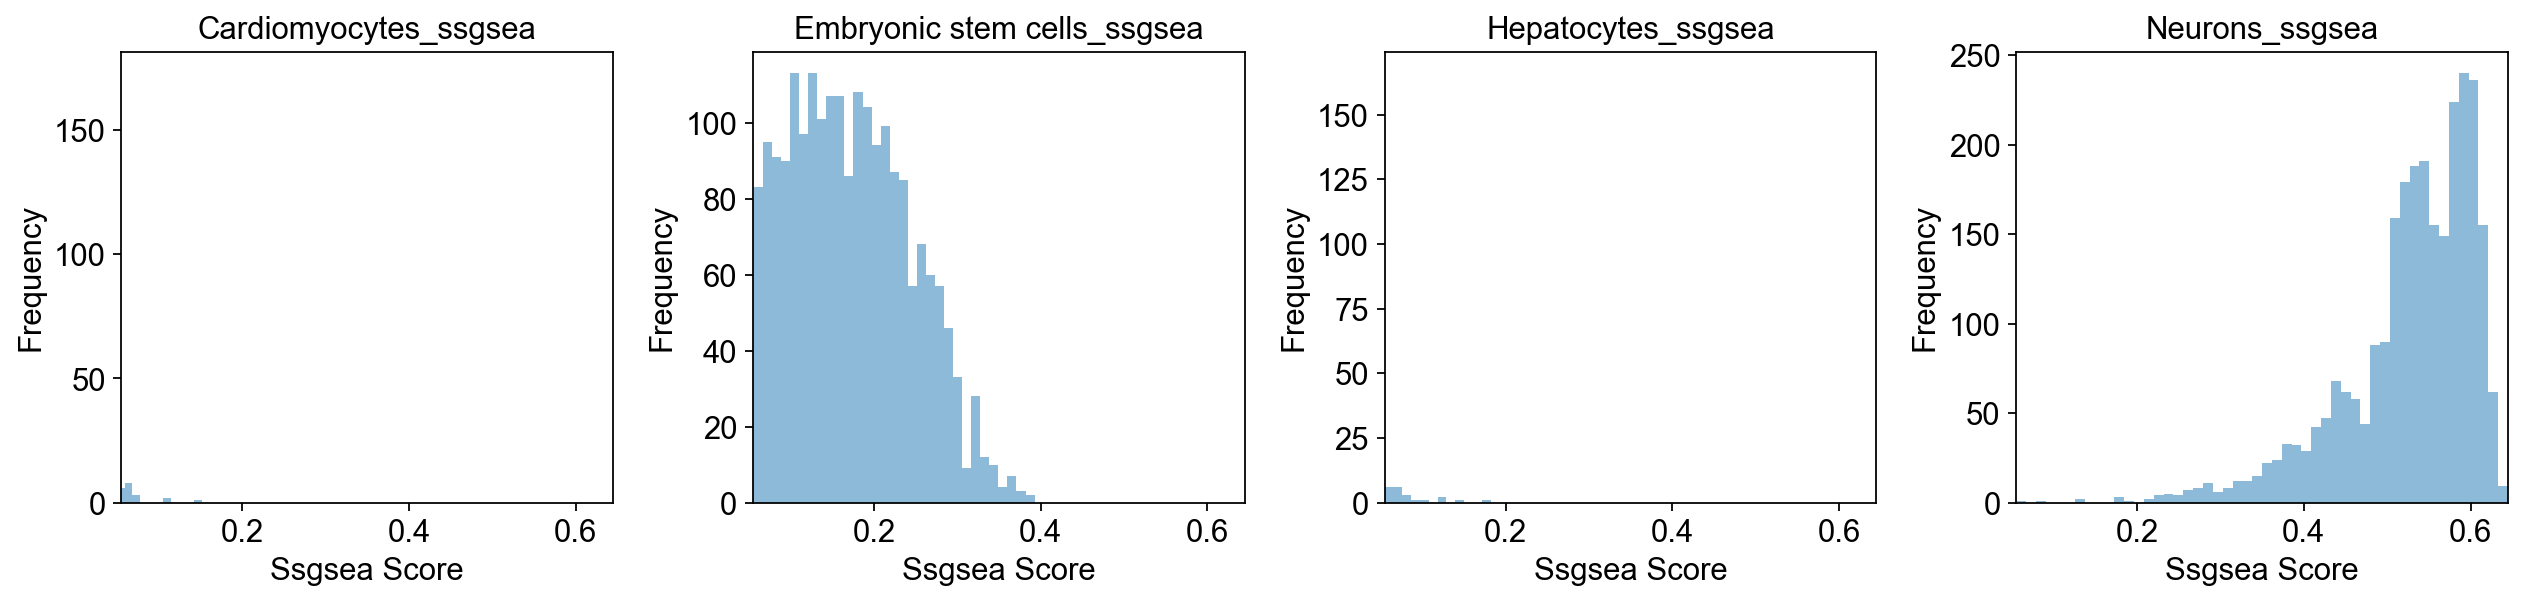

In [21]:
xmin = adata.obs["Neurons_ssgsea"].min()
xmax = adata.obs["Neurons_ssgsea"].max()

ncols = 4
nrows = int(np.ceil(len(ssgsea_scores) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for idx, score_col in enumerate(ssgsea_scores):
    ax = axes[idx // ncols, idx % ncols]
    ax.hist(adata.obs[score_col], bins=50, alpha=0.5)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Ssgsea Score")
    ax.set_ylabel("Frequency")
    ax.set_title(score_col)
    ax.grid(False)

for idx in range(len(ssgsea_scores), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

plt.tight_layout()
plt.savefig(figure_dir + "brain_ssgsea_score_unit_test_histogram.pdf")
plt.show()

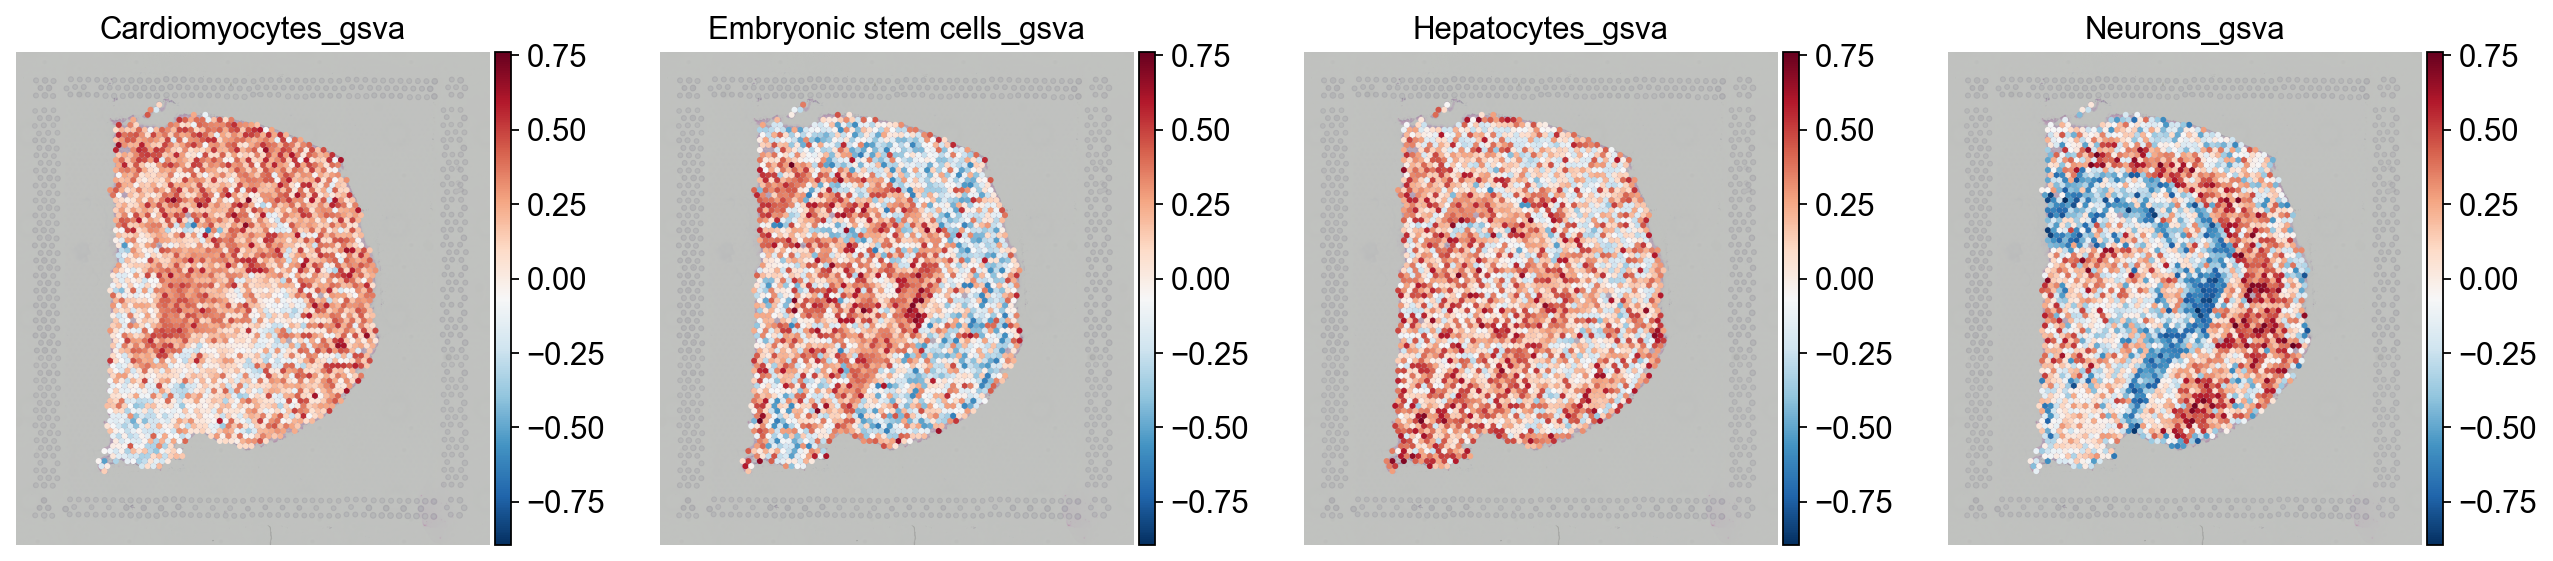

In [22]:
sq.pl.spatial_scatter(
    adata,
    color=gsva_scores,
    cmap="RdBu_r",
    size=1.6,
    img_alpha=0.5,
    ncols=4,
    vmax=adata.obs["Neurons_gsva"].max(),
    vmin=adata.obs["Neurons_gsva"].min(),
    save="brain_gsva_score_unit_test.pdf",
)

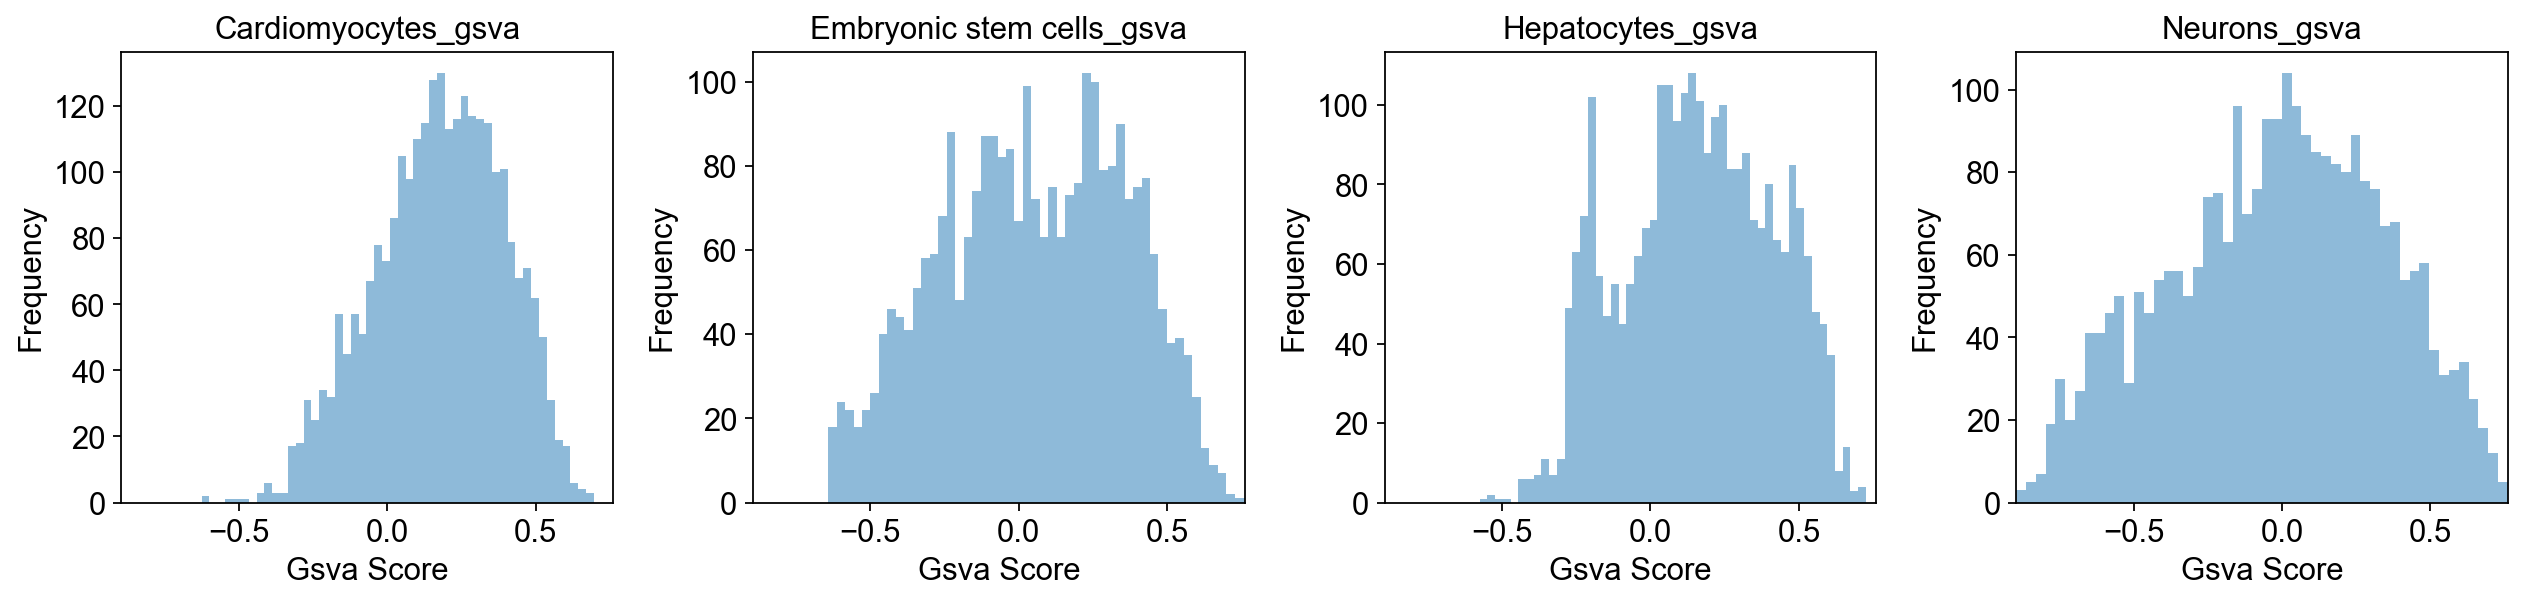

In [23]:
xmin = adata.obs["Neurons_gsva"].min()
xmax = adata.obs["Neurons_gsva"].max()

ncols = 4
nrows = int(np.ceil(len(gsva_scores) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for idx, score_col in enumerate(gsva_scores):
    ax = axes[idx // ncols, idx % ncols]
    ax.hist(adata.obs[score_col], bins=50, alpha=0.5)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Gsva Score")
    ax.set_ylabel("Frequency")
    ax.set_title(score_col)
    ax.grid(False)

for idx in range(len(gsva_scores), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

plt.tight_layout()
plt.savefig(figure_dir + "brain_gsva_score_unit_test_histogram.pdf")
plt.show()

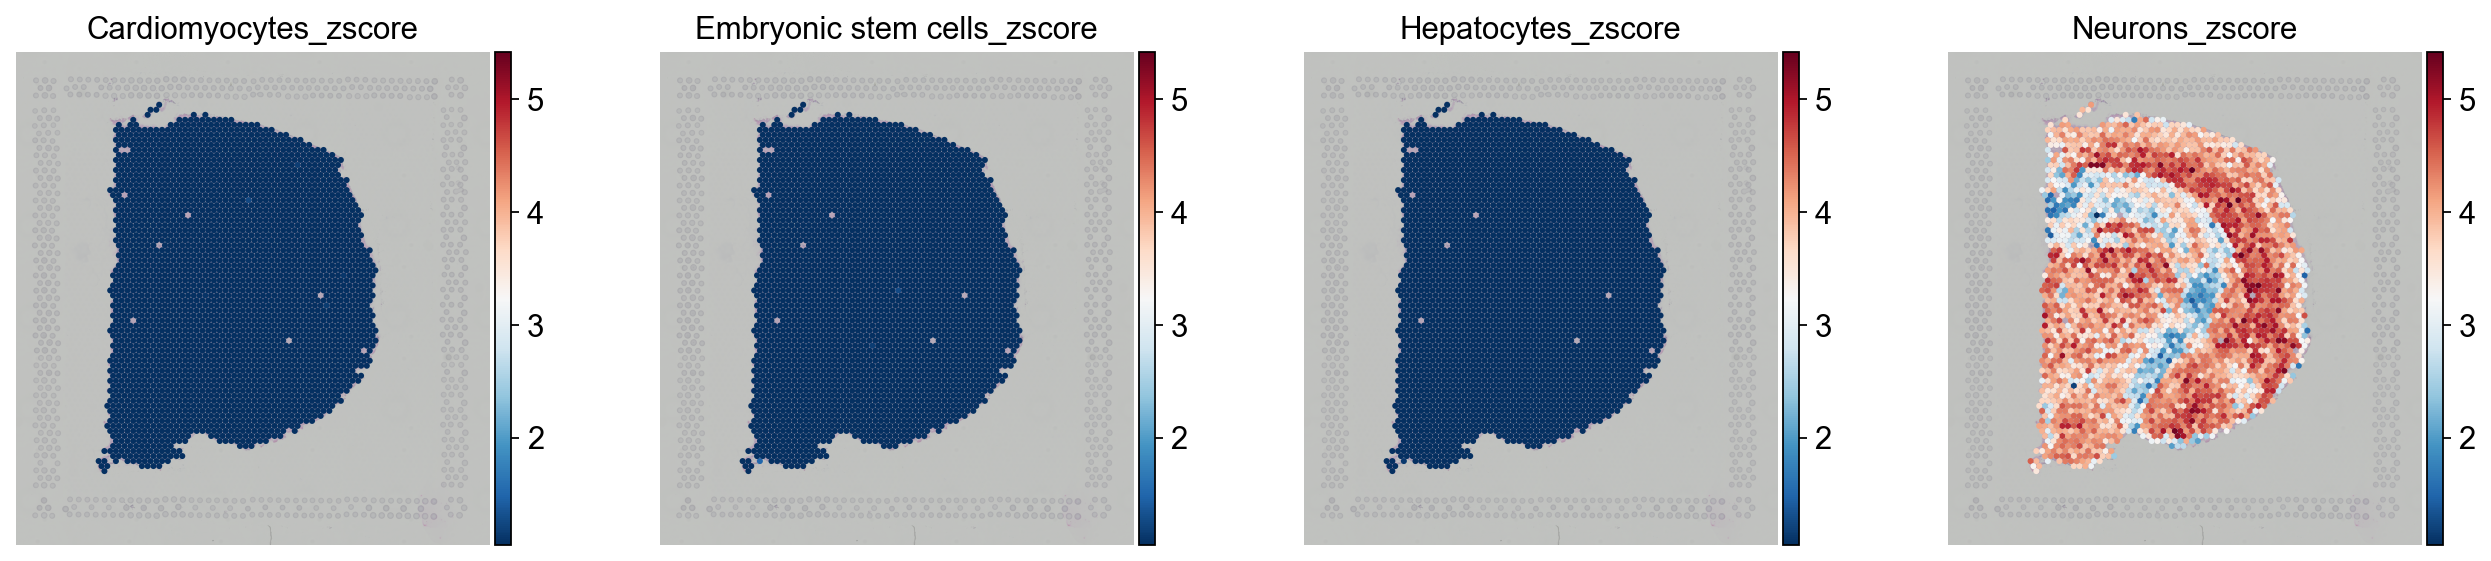

In [24]:
sq.pl.spatial_scatter(
    adata,
    color=zscore_scores,
    cmap="RdBu_r",
    size=1.6,
    img_alpha=0.5,
    ncols=4,
    vmax=adata.obs["Neurons_zscore"].max(),
    vmin=adata.obs["Neurons_zscore"].min(),
    save="brain_zscore_score_unit_test.pdf",
)

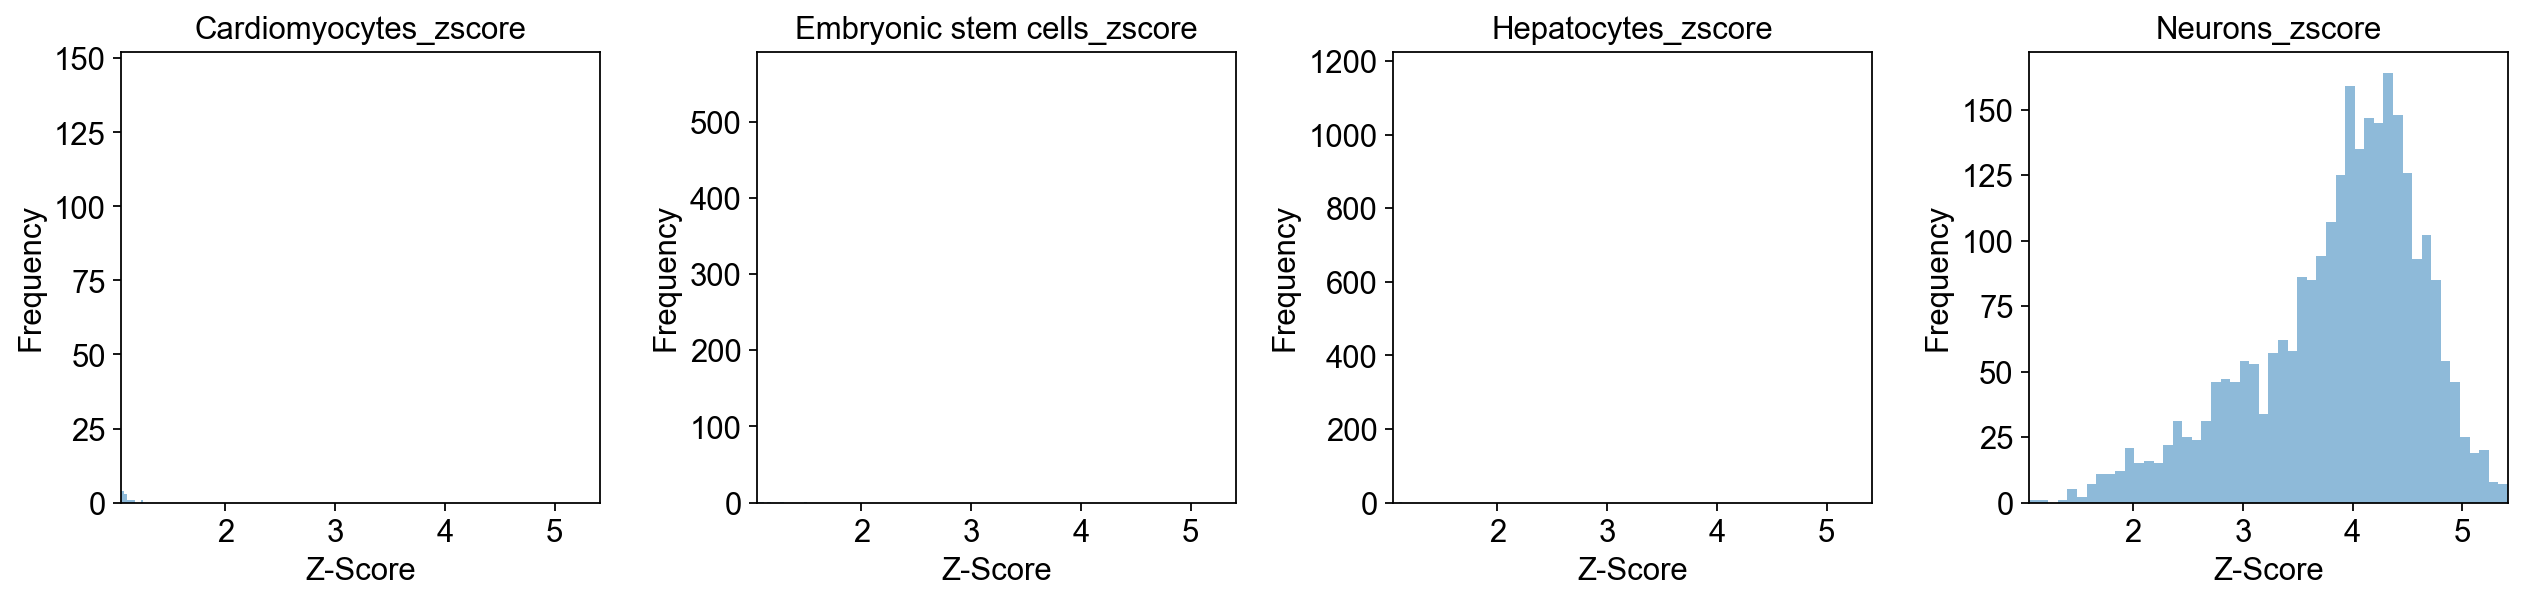

In [25]:
xmin = adata.obs["Neurons_zscore"].min()
xmax = adata.obs["Neurons_zscore"].max()

ncols = 4
nrows = int(np.ceil(len(zscore_scores) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for idx, score_col in enumerate(zscore_scores):
    ax = axes[idx // ncols, idx % ncols]
    ax.hist(adata.obs[score_col], bins=50, alpha=0.5)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Z-Score")
    ax.set_ylabel("Frequency")
    ax.set_title(score_col)
    ax.grid(False)

for idx in range(len(zscore_scores), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

plt.tight_layout()
plt.savefig(figure_dir + "brain_zscore_score_unit_test_histogram.pdf")
plt.show()